In [1]:
import pandas as pd
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

In [2]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [8]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=2)
label = dbscan.fit_predict(X_scaled)

In [6]:
dataset['Category_group'] = label

C:\Anaconda3\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


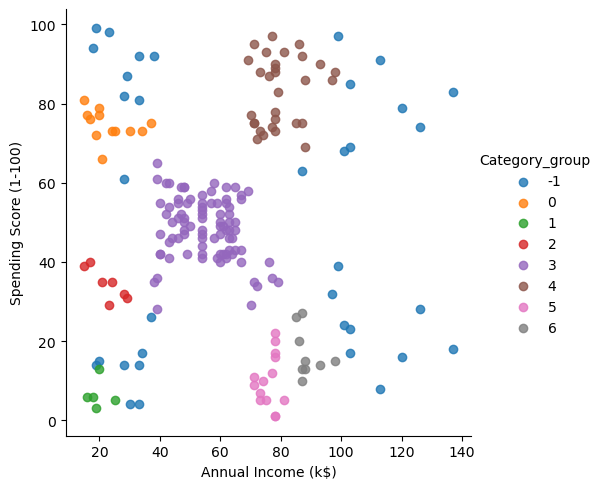

In [9]:
import seaborn as sns
facet = sns.lmplot(data=dataset, x=dataset.columns[3], y=dataset.columns[4],
                    hue=dataset.columns[5], fit_reg=False, legend=True, legend_out=True)

In [11]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, dbscan.labels_)
print(score)

0.374793348539216


In [13]:
from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(X, dbscan.labels_)
print(score)

1.216129026525622
